In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades//3.1/LRG/alltiles_LRGzinfo.fits'))
print(len(zbest))

1083682


In [4]:
zbest[:1]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,TILEID,COADD_NUMEXP,COADD_EXPTIME,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_FIBER_X,MEAN_FIBER_Y,MEAN_FIBER_RA,MEAN_FIBER_DEC,MEAN_FIBERASSIGN_X,MEAN_FIBERASSIGN_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,FIRST_FIBER,LAST_FIBER,FIRST_MJD,LAST_MJD,NUM_MJD,EXPS,TSNR2_ELG,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,EFFTIME_DARK,EFFTIME_BRIGHT,EFFTIME_BACK,subset,TARGETS,FLUX_IVAR_W1,FLUX_IVAR_W2,SV1_SCND_TARGET,RZR,FIBERASSIGN_X,FIBERASSIGN_Y,NUM_ITER,FIBER_X,FIBER_Y,FIBER_RA,FIBER_DEC,EXPTIME
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,int64,uint8,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,int64,int16,float32,float64,float64,float64,float64,float32,float32,float64,float64,float32,float32,int32,int32,int16,int32,int32,int16,int32,int32,int64,int64,float32,float32,int16,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,str7,float32,float32,int64,str20,float32,float32,int64,float64,float64,float64,float64,float64
39627061832188430,8.999999999999996e+99,0.0 .. 0.0,-0.0019957014509158224,4.131159871613317e-48,1570,0,STAR,CV,3,1.942668892225729e+84,1,483,1483,525,512,59.13766874039387,-31.416376752441742,0.0,0.0,2021.0034,1152921504732676217,1,2000,0.9599592140823241,5,DEV,5.2833138,26.431753,60.96162,183.13593,96.25868,11.123175,0,,0.0,0.0,0.0,0.0,0.01027304,90.07469,48.78619,0.64739597,3.2388406,7.469991,0.64739895,3.2388556,7.4700236,0,4.0,5.448823,0.3788447,-0.1879785,S,1152921504732676217,131074,0,2000,1,9010,158016,0592m315,526,1e+20,80638,0,0.0,-1.3569999933242798,1.3570059537887573,-0.6265000104904175,0.6266916990280151,188.68,-358.4605,59.131428522180386,-31.41385571671585,187.41061,-359.45877,20210103,20210103,1,70701,70702,2,80638,80638,525,525,59218.17,59218.176,2,"70701,70702",17.789527893066406,1255.2828369140625,4.405727386474609,13.508369445800781,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,deep,BGS+MWS,1e+20,1e+20,999999,N,1e+20,1e+20,999999,1e+20,1e+20,1e+20,1e+20,1e+20


In [5]:
mask = zbest['subset']=='deep'
print(np.sum(mask))
mask &= zbest['TARGETS']=='QSO+LRG'
print(np.sum(mask))

zbest = zbest[mask]
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

58113
34868
34868
34702


In [6]:
' '.join(zbest.colnames)

'TARGETID CHI2 COEFF Z ZERR ZWARN NPIXELS SPECTYPE SUBTYPE NCOEFF DELTACHI2 PETAL_LOC DEVICE_LOC LOCATION FIBER FIBERSTATUS TARGET_RA TARGET_DEC PMRA PMDEC REF_EPOCH FA_TARGET FA_TYPE PRIORITY SUBPRIORITY OBSCONDITIONS MORPHTYPE FLUX_G FLUX_R FLUX_Z FLUX_IVAR_G FLUX_IVAR_R FLUX_IVAR_Z REF_ID REF_CAT GAIA_PHOT_G_MEAN_MAG GAIA_PHOT_BP_MEAN_MAG GAIA_PHOT_RP_MEAN_MAG PARALLAX EBV FLUX_W1 FLUX_W2 FIBERFLUX_G FIBERFLUX_R FIBERFLUX_Z FIBERTOTFLUX_G FIBERTOTFLUX_R FIBERTOTFLUX_Z MASKBITS SERSIC SHAPE_R SHAPE_E1 SHAPE_E2 PHOTSYS SV1_DESI_TARGET SV1_BGS_TARGET SV1_MWS_TARGET PRIORITY_INIT NUMOBS_INIT RELEASE BRICKID BRICKNAME BRICK_OBJID BLOBDIST TILEID COADD_NUMEXP COADD_EXPTIME MEAN_DELTA_X RMS_DELTA_X MEAN_DELTA_Y RMS_DELTA_Y MEAN_FIBER_X MEAN_FIBER_Y MEAN_FIBER_RA MEAN_FIBER_DEC MEAN_FIBERASSIGN_X MEAN_FIBERASSIGN_Y FIRST_NIGHT LAST_NIGHT NUM_NIGHT FIRST_EXPID LAST_EXPID NUM_EXPID FIRST_TILEID LAST_TILEID FIRST_FIBER LAST_FIBER FIRST_MJD LAST_MJD NUM_MJD EXPS TSNR2_ELG TSNR2_BGS TSNR2_QSO TS

In [7]:
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t['efftime'] = 0
t['n_exp'] = 0
for index, tileid in enumerate(t['TILEID']):
    mask = zbest['TILEID']==tileid
    t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
    t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
t

TILEID,count,efftime,n_exp
int64,int64,int64,int64
80605,2117,7018,11
80607,1922,9700,15
80609,2125,8303,13
80620,2049,6924,9
80622,1900,5390,6
80670,1894,1522,3
80674,1691,2749,6
80676,1641,4807,11
80678,1686,4880,10


In [8]:
mask = t['efftime']>=2000
print(np.sum(mask), np.sum(~mask))

mask = t['efftime']>=3000
print(np.sum(mask), np.sum(~mask))

mask = t['efftime']>=4000
print(np.sum(mask), np.sum(~mask))

18 2
17 3
13 7


/global/common/software/desi/cori/desiconda/20200801-1.4.0-spec/conda/lib/python3.8/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


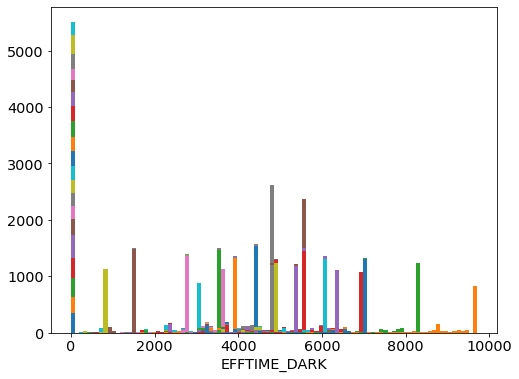

In [9]:
plt.figure(figsize=(8, 6))
tileid_list = np.unique(zbest['TILEID'])
tmp = []
for tileid in tileid_list:
    mask = zbest['TILEID']==tileid
    tmp.append(zbest['EFFTIME_DARK'][mask])
plt.hist(tmp, 100, label=tileid_list, range=(0, zbest['EFFTIME_DARK'].max()), histtype='barstacked')
plt.xlabel('EFFTIME_DARK')
# plt.legend()
plt.show()

In [10]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
18686


/global/common/software/desi/cori/desiconda/20200801-1.4.0-spec/conda/lib/python3.8/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


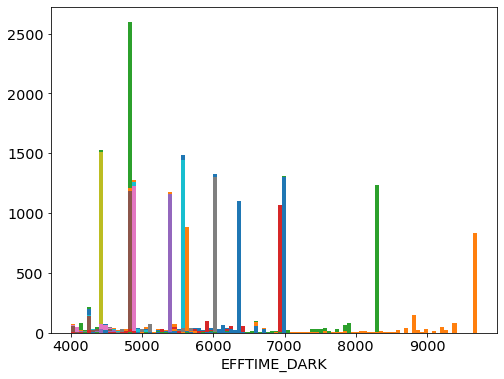

In [16]:
plt.figure(figsize=(8, 6))
tileid_list = np.unique(zbest['TILEID'])
tmp = []
for tileid in tileid_list:
    mask = zbest['TILEID']==tileid
    tmp.append(zbest['EFFTIME_DARK'][mask])
plt.hist(tmp, 100, label=tileid_list, range=(zbest['EFFTIME_DARK'].min(), zbest['EFFTIME_DARK'].max()), histtype='barstacked')
plt.xlabel('EFFTIME_DARK')
# plt.legend()
plt.show()

In [72]:
mask = np.in1d(zbest['TILEID'], [80676, 80678, 80680])

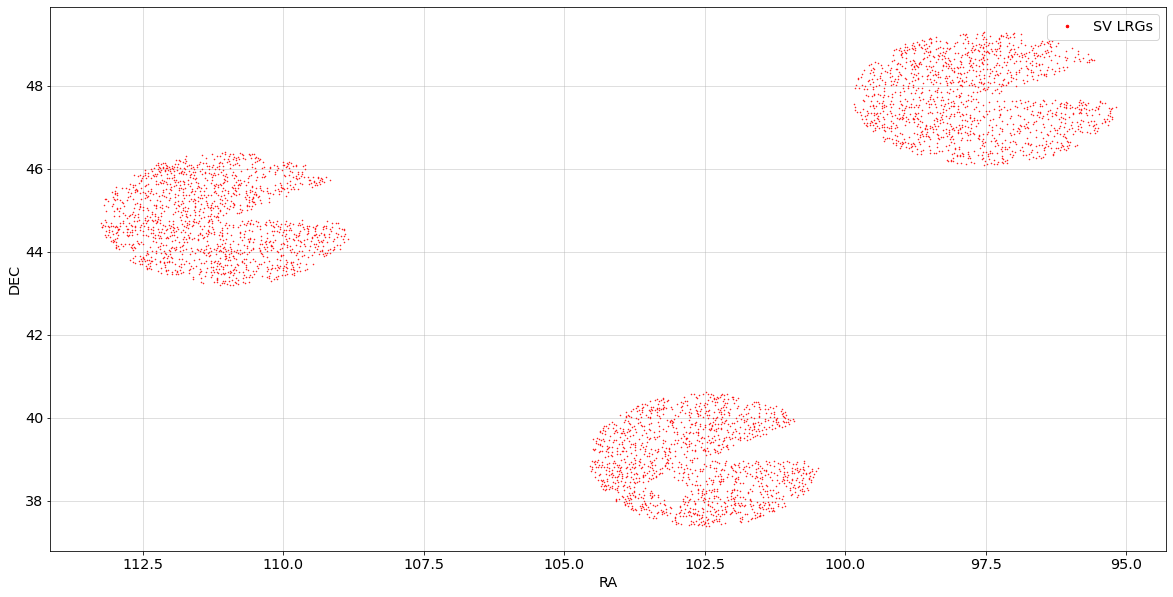

In [74]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'][mask], zbest['TARGET_DEC'][mask], 'r.', ms=1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

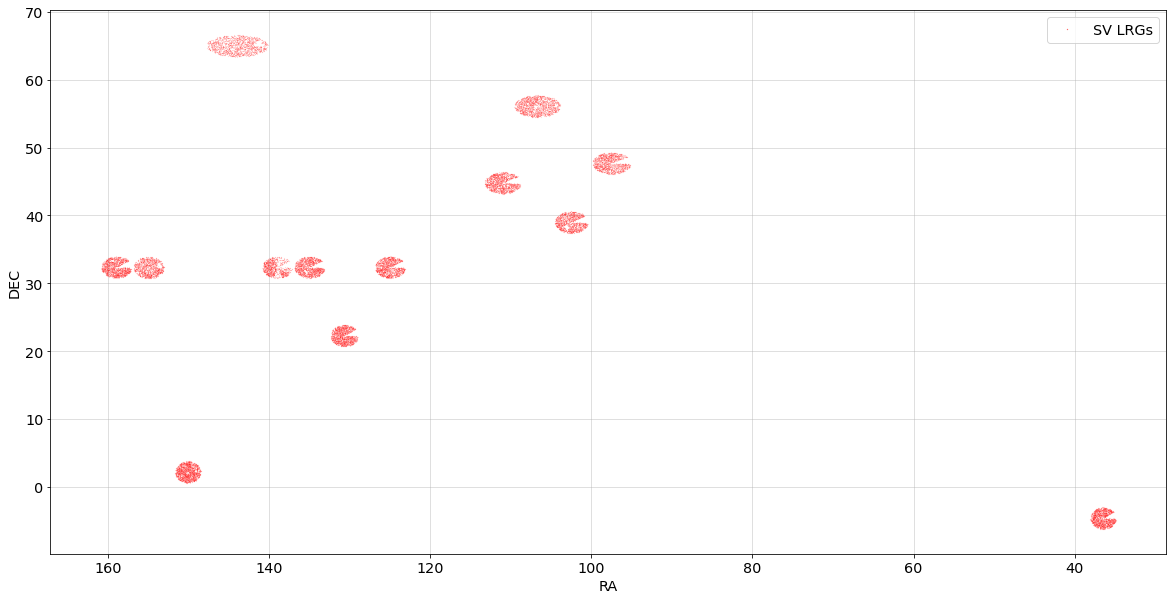

In [12]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

__Add sweep columns__

In [13]:
# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

In [14]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']

# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(zbest, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, zbest['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # if '/south/sweep/' in sweep_fn:
    #     ls['field'] = 'south'
    # else:
    #     ls['field'] = 'north'
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(zbest), len(ls))

# # This only works if the objects are unique
# _, idx1, idx2 = np.intersect1d(zbest['TARGETID'], ls['TARGETID'], return_indices=True)
# print(len(zbest), len(idx1), len(zbest)-len(idx1))
# zbest = zbest[idx1]
# ls = ls[idx2]

zbest = join(zbest, ls, keys='TARGETID')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

31
18686 18686


In [19]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

4865
5173
18686

466
466
39


In [20]:
mask_zwarn = zbest['ZWARN']==0
print(np.sum((~mask_zwarn) & lrg_opt), np.sum((~mask_zwarn) & lrg_opt)/np.sum(lrg_opt))
print(np.sum((~mask_zwarn) & lrg_ir), np.sum((~mask_zwarn) & lrg_ir)/np.sum(lrg_ir))
print(np.sum((~mask_zwarn) & lrg_sv), np.sum((~mask_zwarn) & lrg_sv)/np.sum(lrg_sv))

8 0.001644398766700925
12 0.002319737096462401
162 0.008669592208070212


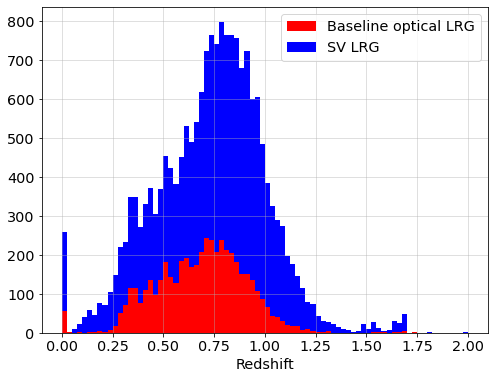

In [21]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=80, range=(0, 2.0), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=80, range=(0, 2.0), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

No ZWARN cut:


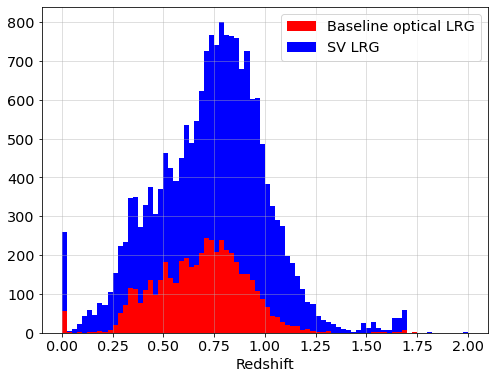

In [22]:
print('No ZWARN cut:')
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=80, range=(0, 2.0), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=80, range=(0, 2.0), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

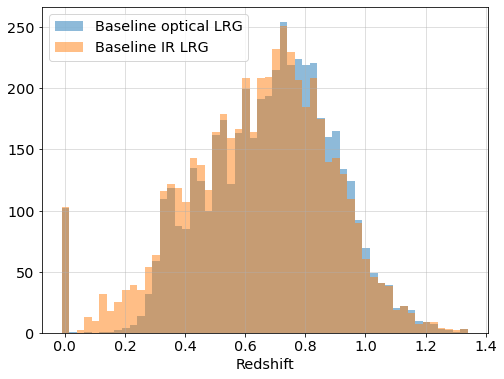

In [42]:
bins = np.arange(-0.01, 1.35, 0.025)

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=bins, label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn], bins=bins, label='Baseline IR LRG', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
# plt.ylim(ymax=100)
plt.show()

In [43]:
print('Z > 1.5 LRG targets:')
mask = (zbest['Z']>1.5) & lrg_sv
print('{:.1f}%'.format(np.sum(mask)/np.sum(lrg_sv)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

Z > 1.5 LRG targets:
1.2%


tileid,counts,frac (%)
int64,int64,float64
80605,22,10.0
80607,15,6.8
80609,33,14.9
80620,4,1.8
80622,11,5.0
80676,30,13.6
80678,32,14.5
80680,17,7.7
80682,17,7.7


--------
# Low-z contamination

In [71]:
mask_lowz = (zbest['Z']<0.2) & (zbest['SPECTYPE']!='STAR')

mask = lrg_opt & mask_zwarn
print('LRG_OPT: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_ir & mask_zwarn
print('LRG_IR: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_sv & mask_zwarn
print('LRG_SV: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

LRG_OPT: 0.2%
LRG_IR: 2.3%
LRG_SV: 1.4%


In [50]:
mask_lowz = (zbest['Z']<0.3) & (zbest['SPECTYPE']!='STAR')

mask = lrg_opt & mask_zwarn
print('LRG_OPT: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_ir & mask_zwarn
print('LRG_IR: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

mask = lrg_sv & mask_zwarn
print('LRG_SV: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

LRG_OPT: 1.9%
LRG_IR: 5.7%
LRG_SV: 4.4%


__Reintroduce g-band-based low-z cuts to the low-z selection__

In [51]:
# South
lowz_cut_south = (zbest['gmag'] - zbest['w1mag'] > 2.6) & (zbest['gmag'] - zbest['rmag'] > 1.4) # low-z cut
lowz_cut_south |= (zbest['rmag']-zbest['w1mag']) > 1.8                   # ignore low-z cut for faint objects
# print(np.sum(lowz_cut_south))

# North
lowz_cut_north = (zbest['gmag'] - zbest['w1mag'] > 2.67) & (zbest['gmag'] - zbest['rmag'] > 1.45)  # low-z cut
lowz_cut_north |= (zbest['rmag']-zbest['w1mag']) > 1.85                         # ignore low-z cut for faint objects
# print(np.sum(lowz_cut_north))

mask_south = zbest['PHOTSYS']=='S'
# print(np.sum(mask_south))
mask_north = zbest['PHOTSYS']=='N'
# print(np.sum(mask_north))
lowz_cut = (lowz_cut_south & mask_south) | (lowz_cut_north & mask_north)
# print(np.sum(lowz_cut))

print(np.sum(lrg_ir)-np.sum(lrg_ir & lowz_cut), (np.sum(lrg_ir)-np.sum(lrg_ir & lowz_cut))/np.sum(lrg_ir))
print(np.sum(lrg_opt)-np.sum(lrg_opt & lowz_cut), (np.sum(lrg_opt)-np.sum(lrg_opt & lowz_cut))/np.sum(lrg_opt))

375 0.07249178426445003
0 0.0


LRG_IR: 2.2%


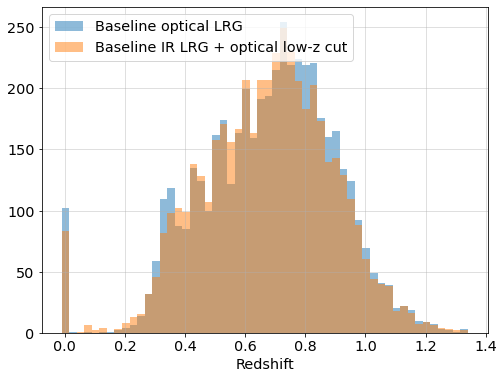

In [52]:
mask = lrg_ir & mask_zwarn & lowz_cut
print('LRG_IR: {:.1f}%'.format(np.sum(mask & mask_lowz)/np.sum(mask)*100))

bins = np.arange(-0.01, 1.35, 0.025)
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=bins, label='Baseline optical LRG', alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn & lowz_cut], bins=bins, label='Baseline IR LRG + optical low-z cut', alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
# plt.ylim(ymax=100)
plt.show()

--------
# Stellar contamination

In [53]:
print('LRG_OPT:')
mask = lrg_opt & mask_zwarn
print(np.sum(mask))
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT:
4857


type,counts,frac (%)
str6,int64,float64
GALAXY,4725,97.3
QSO,31,0.6
STAR,101,2.1


In [54]:
print('LRG_IR:')
mask = lrg_ir & mask_zwarn
print(np.sum(mask))
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR:
5161


type,counts,frac (%)
str6,int64,float64
GALAXY,4874,94.4
QSO,185,3.6
STAR,102,2.0


In [55]:
print('LRG_SV:')
mask = lrg_sv & mask_zwarn
print(np.sum(mask))
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV:
18524


type,counts,frac (%)
str6,int64,float64
GALAXY,17632,95.2
QSO,441,2.4
STAR,451,2.4


In [87]:
mask = (zbest['MORPHTYPE']=='PSF') & mask_zwarn & lrg_sv
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

type,counts,frac (%)
str6,int64,float64
GALAXY,820,58.6
QSO,186,13.3
STAR,393,28.1


In [104]:
np.unique(zbest['SUBTYPE'])

""
F
G
K
M


In [102]:
mask = (zbest['SPECTYPE']=='STAR') & mask_zwarn & lrg_opt
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,TILEID,COADD_NUMEXP,COADD_EXPTIME,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_FIBER_X,MEAN_FIBER_Y,MEAN_FIBER_RA,MEAN_FIBER_DEC,MEAN_FIBERASSIGN_X,MEAN_FIBERASSIGN_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,FIRST_FIBER,LAST_FIBER,FIRST_MJD,LAST_MJD,NUM_MJD,EXPS,TSNR2_ELG,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,EFFTIME_DARK,EFFTIME_BRIGHT,EFFTIME_BACK,subset,TARGETS,FLUX_IVAR_W1,FLUX_IVAR_W2,SV1_SCND_TARGET,RZR,FIBERASSIGN_X,FIBERASSIGN_Y,NUM_ITER,FIBER_X,FIBER_Y,FIBER_RA,FIBER_DEC,EXPTIME,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,gmag,rmag,zmag,w1mag,w2mag,gfibermag,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,int64,uint8,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,int64,int16,float32,float64,float64,float64,float64,float32,float32,float64,float64,float32,float32,int32,int32,int16,int32,int32,int16,int32,int32,int64,int64,float32,float32,int16,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,str7,float32,float32,int64,str20,float32,float32,int64,float64,float64,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39627670631226896,41470.421237210016,-1227.0631748190115 .. 0.0,-4.890552863510987e-06,1.8707761776378853e-06,0,7929,STAR,M,5,44100.718048831244,2,434,2434,1474,0,35.05384352700487,-4.7923116410533755,0.0,0.0,2020.9487,41943081,1,3200,0.2652412495250299,1,PSF,0.46197674,2.220406,10.72021,1610.3171,743.8867,139.18456,0,,0.0,0.0,0.0,0.0,0.020624584,23.675903,24.178036,0.35984418,1.7295247,8.350215,4.3350196,16.13527,57.380722,0,0.0,0.0,0.0,0.0,S,41943081,0,0,3200,1,0,0,,0,0.0,80605,11,9458.1875,-0.001181818195618689,0.005567764397710562,-0.0029090908356010914,0.0047673131339251995,348.79346,-47.911728,35.053855535714135,-4.792317564423123,348.86026,-47.9213,20201215,20210205,4,67972,74783,11,80605,80605,1474,1474,59199.164,59251.14,11,"67972,67975,68290,68291,68292,73702,74779,74780,74781,74782,74783",730.5437622070312,43804.62890625,182.0247802734375,476.1322021484375,7455.5001220703125,7274.300079345703,8066.199935913086,5483.048812866211,6047.934020996094,7264.047210693359,7018.350250244141,7086.656341552734,6825.825500488281,deep,QSO+LRG,1e+20,1e+20,999999,N,1e+20,1e+20,999999,1e+20,1e+20,1e+20,1e+20,1e+20,0.9407734,0.959708,0.9772585,0.99651086,0.9978558,23.272161,21.589266,19.899515,19.060438,19.039116,23.543427,21.86053,20.17078,-4.890552863510987e-06
39627682698239034,12841.05703728674,-170.1939946763328 .. 0.0,-6.963101505189353e-05,1.2269743315493215e-05,0,7928,STAR,M,5,1806.979183178115,4,30,4030,2121,0,36.24237925562549,-4.235496909216657,0.0,0.0,2020.9487,125829241,1,3200,0.548927455327992,1,PSF,0.031197298,0.29309866,3.583516,3408.5273,1872.7367,197.51434,0,,0.0,0.0,0.0,0.0,0.027307762,19

In [86]:
mask = (zbest['MORPHTYPE']=='PSF') & mask_zwarn & lrg_opt
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

type,counts,frac (%)
str6,int64,float64
GALAXY,51,35.9
QSO,6,4.2
STAR,85,59.9


In [84]:
mask = (zbest['SPECTYPE']=='STAR') & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['MORPHTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

type,counts,frac (%)
str4,int64,float64
DEV,20,4.4
EXP,15,3.3
PSF,393,87.1
REX,14,3.1
SER,9,2.0


In [96]:
mask0 = lrg_opt & mask_zwarn & (zbest['MASKBITS'] & 2**8==0)
print(np.sum(mask0))
mask = (zbest['SPECTYPE']=='STAR') & mask0
print(np.sum(mask)/np.sum(mask0)*100)

4720
1.3347457627118644


In [98]:
1.3/2

0.65

In [105]:
mask0 = lrg_opt & mask_zwarn & (~np.in1d(zbest['TILEID'], [80676, 80678, 80680]))
mask = (zbest['SPECTYPE']=='STAR') & mask0
print(np.sum(mask)/np.sum(mask0)*100)

1.0512483574244416


In [97]:
mask0 = lrg_opt & mask_zwarn & (zbest['MASKBITS'] & 2**8>0)
print(np.sum(mask0))
mask = (zbest['SPECTYPE']=='STAR') & mask0
print(np.sum(mask)/np.sum(mask0)*100)

137
27.73722627737226


In [99]:
mask = (zbest['SPECTYPE']=='STAR') & lrg_opt & mask_zwarn
print(np.sum(mask)/np.sum(lrg_opt & mask_zwarn)*100)

2.0794729256742848


In [100]:
mask = (zbest['SPECTYPE']=='STAR') & lrg_ir & mask_zwarn
print(np.sum(mask)/np.sum(lrg_ir & mask_zwarn)*100)

1.9763611703158304


In [91]:
mask = (zbest['SPECTYPE']=='STAR') & lrg_opt & mask_zwarn
print(np.sum(mask)/np.sum(lrg_opt & mask_zwarn)*100)

idx = np.where(mask)[0]
print(len(idx))
if len(idx)>200:
    idx = np.random.choice(idx, size=200, replace=False)
t = Table()
t['RA'] = zbest['TARGET_RA'][idx]
t['DEC'] = zbest['TARGET_DEC'][idx]
# t.write('/Users/rongpu/Downloads/visual_inspection.txt', format='ascii.no_header', overwrite=True)
t.write('/global/u2/r/rongpu/temp/visual_inspection.txt', format='ascii.no_header', overwrite=True)

2.0794729256742848
101


In [81]:
# LRG_OPT

print('Stars:')
mask = (zbest['SPECTYPE']=='STAR') & lrg_opt
print('{:.1f}%'.format(np.sum(mask)/np.sum(lrg_opt)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_opt], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

Stars:
2.1%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,415,2,0.5
80607,441,18,4.1
80620,364,4,1.1
80622,325,1,0.3
80676,326,18,5.5
80678,336,24,7.1
80680,391,19,4.9
80682,386,8,2.1
80688,397,1,0.3


In [82]:
# LRG SV

print('Stars:')
mask = (zbest['SPECTYPE']=='STAR') & lrg_sv
print('{:.1f}%'.format(np.sum(mask)/np.sum(lrg_sv)*100))

t = Table()
t['tileid'], t['counts'] = np.unique(zbest['TILEID'][lrg_sv], return_counts=True)
t1 = Table()
t1['tileid'], t1['counts_star'] = np.unique(zbest['TILEID'][mask], return_counts=True)
t = join(t, t1)
t['star frac (%)'] = t['counts_star']/t['counts']*100
t['star frac (%)'].format = '%.1f'
# t.sort('counts')
t

Stars:
2.4%


tileid,counts,counts_star,star frac (%)
int64,int64,int64,float64
80605,1578,10,0.6
80607,1585,63,4.0
80609,1700,10,0.6
80620,1439,19,1.3
80622,1241,13,1.0
80676,1366,91,6.7
80678,1364,96,7.0
80680,1498,74,4.9
80682,1436,27,1.9


In [57]:
mask_star = zbest['SPECTYPE']=='STAR'
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_qso = zbest['SPECTYPE']=='QSO'

In [58]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

451
221


In [59]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

101
57


In [60]:
mask = lrg_sv & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,TILEID,COADD_NUMEXP,COADD_EXPTIME,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_FIBER_X,MEAN_FIBER_Y,MEAN_FIBER_RA,MEAN_FIBER_DEC,MEAN_FIBERASSIGN_X,MEAN_FIBERASSIGN_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,FIRST_FIBER,LAST_FIBER,FIRST_MJD,LAST_MJD,NUM_MJD,EXPS,TSNR2_ELG,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,EFFTIME_DARK,EFFTIME_BRIGHT,EFFTIME_BACK,subset,TARGETS,FLUX_IVAR_W1,FLUX_IVAR_W2,SV1_SCND_TARGET,RZR,FIBERASSIGN_X,FIBERASSIGN_Y,NUM_ITER,FIBER_X,FIBER_Y,FIBER_RA,FIBER_DEC,EXPTIME,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,gmag,rmag,zmag,w1mag,w2mag,gfibermag,rfibermag,zfibermag
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,int64,uint8,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,int64,int16,float32,float64,float64,float64,float64,float32,float32,float64,float64,float32,float32,int32,int32,int16,int32,int32,int16,int32,int32,int64,int64,float32,float32,int16,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,str7,float32,float32,int64,str20,float32,float32,int64,float64,float64,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
39627652604104367,17833.791020933262,-532.5123148105031 .. 0.0,-0.00019300972318158702,3.2991605056021395e-06,0,7929,STAR,M,5,15534.238497015365,9,201,9201,4997,0,37.00360839428921,-5.4212539719879125,0.0,0.0,2020.9487,144115188109541413,1,3400,0.24154191816903792,1,PSF,0.14638636,0.67018497,3.638404,3231.3328,1824.0355,280.9632,0,,0.0,0.0,0.0,0.0,0.024995716,7.457706,6.593612,0.11379531,0.52097684,2.8283598,1.2136408,4.488494,16.641754,0,0.0,0.0,0.0,0.0,S,144115188109541413,0,0,3400,1,0,0,,0,0.0,80605,11,9458.1875,0.0022727272007614374,0.004542726557701826,-0.0021818182431161404,0.004972652532160282,-136.31854,-202.75964,37.00360499394646,-5.421262665283281,-136.32451,-202.78194,20201215,20210205,4,67972,74783,11,80605,80605,4997,4997,59199.164,59251.14,11,"67972,67975,68290,68291,68292,73702,74779,74780,74781,74782,74783",782.2117919921875,47894.03125,198.7999725341797,500.3840026855469,7455.5001220703125,7274.300079345703,8066.199935913086,5483.048812866211,6047.934020996094,7264.047210693359,7018.350250244141,7086.656341552734,6825.825500488281,deep,QSO+LRG,1e+20,1e+20,999999,N,1e+20,1e+20,999999,1e+20,1e+20,1e+20,1e+20,1e+20,0.92867875,0.9513793,0.9725055,0.99577296,0.9974019,24.505913,22.880398,21.067453,20.313889,20.449368,24.779352,23.15384,21.340893
39627658627129869,13444.759493793072,-118.50383599623903 .. 0.0,-7.842609366632206e-05,1.3049297663473507e-05,0,7928,STAR,M,5,1202.0657203172432,8,346,8346,4013,0,37.60164787246255,-5.126373808139448,0.0,0.0,2020.9487,33554465,1,3200,0.591795319749653,1,PSF,0.24964918,0.9069388,4.6216273,4058.3818,2370.2207,312.9644,0,,0.0,0.0,0.0,0.0,0.027333157,8.20765,10.542

In [61]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [62]:
zbest['z_phot'] = zbest['Z']

4756


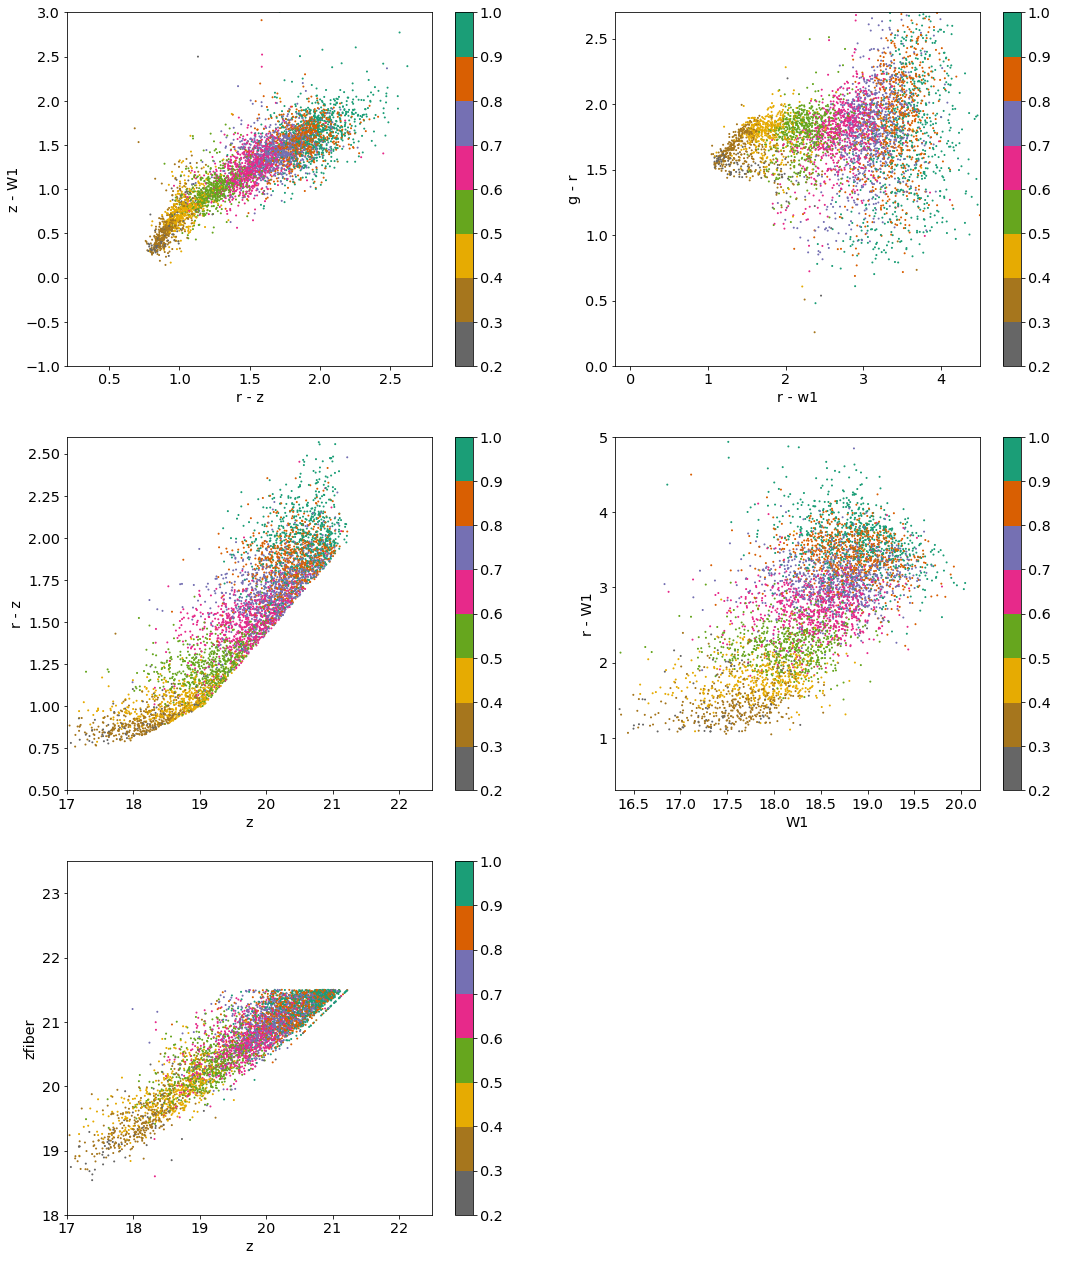

In [69]:
mask = lrg_opt & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=1)

101


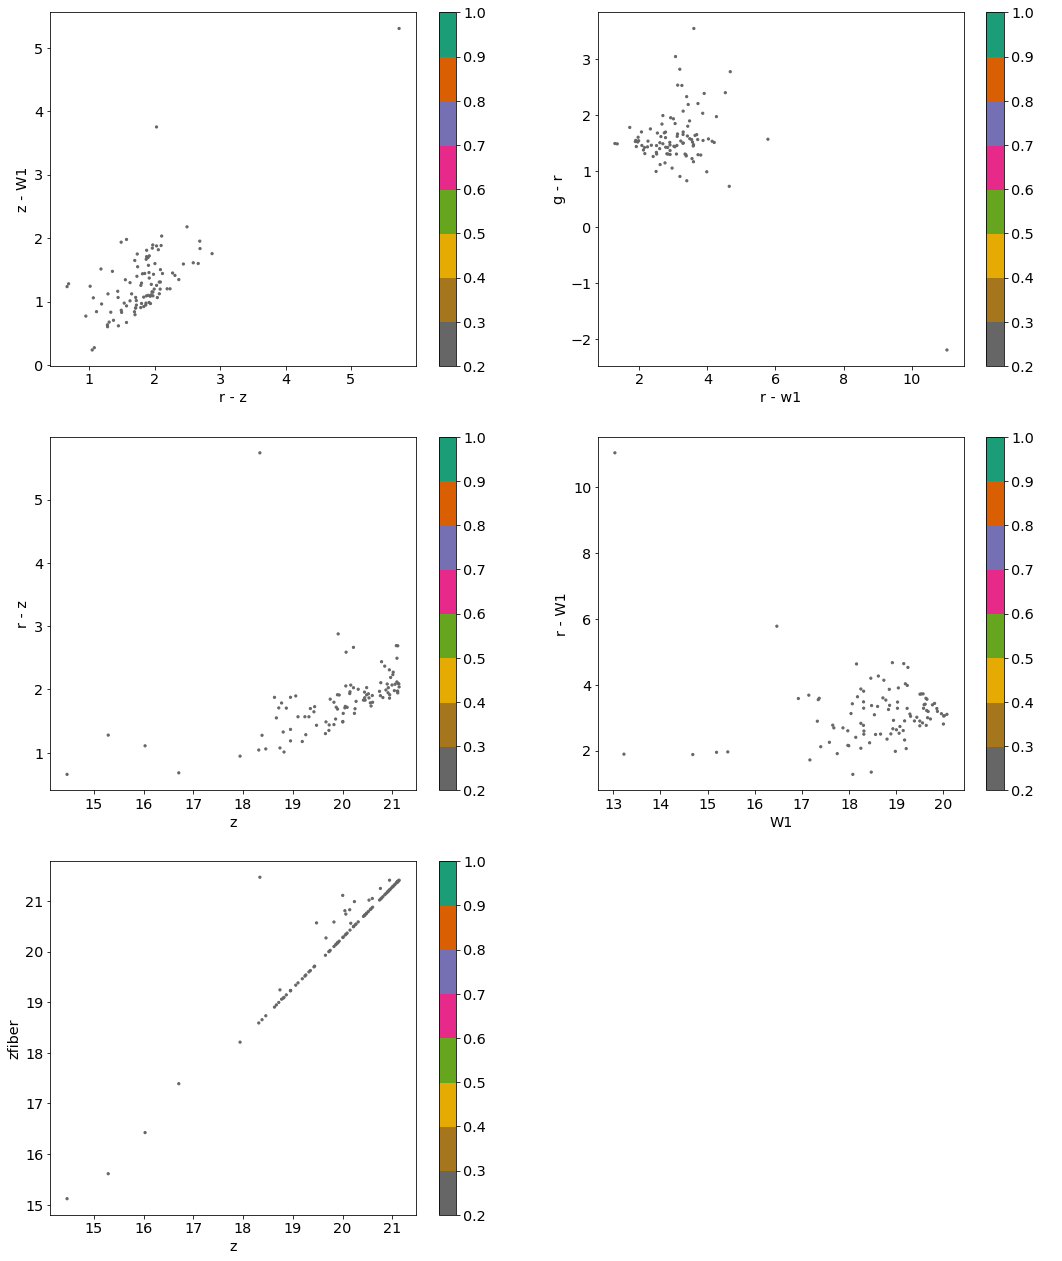

In [77]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
color_plot_3x2_new(zbest[mask], ms=5)

101


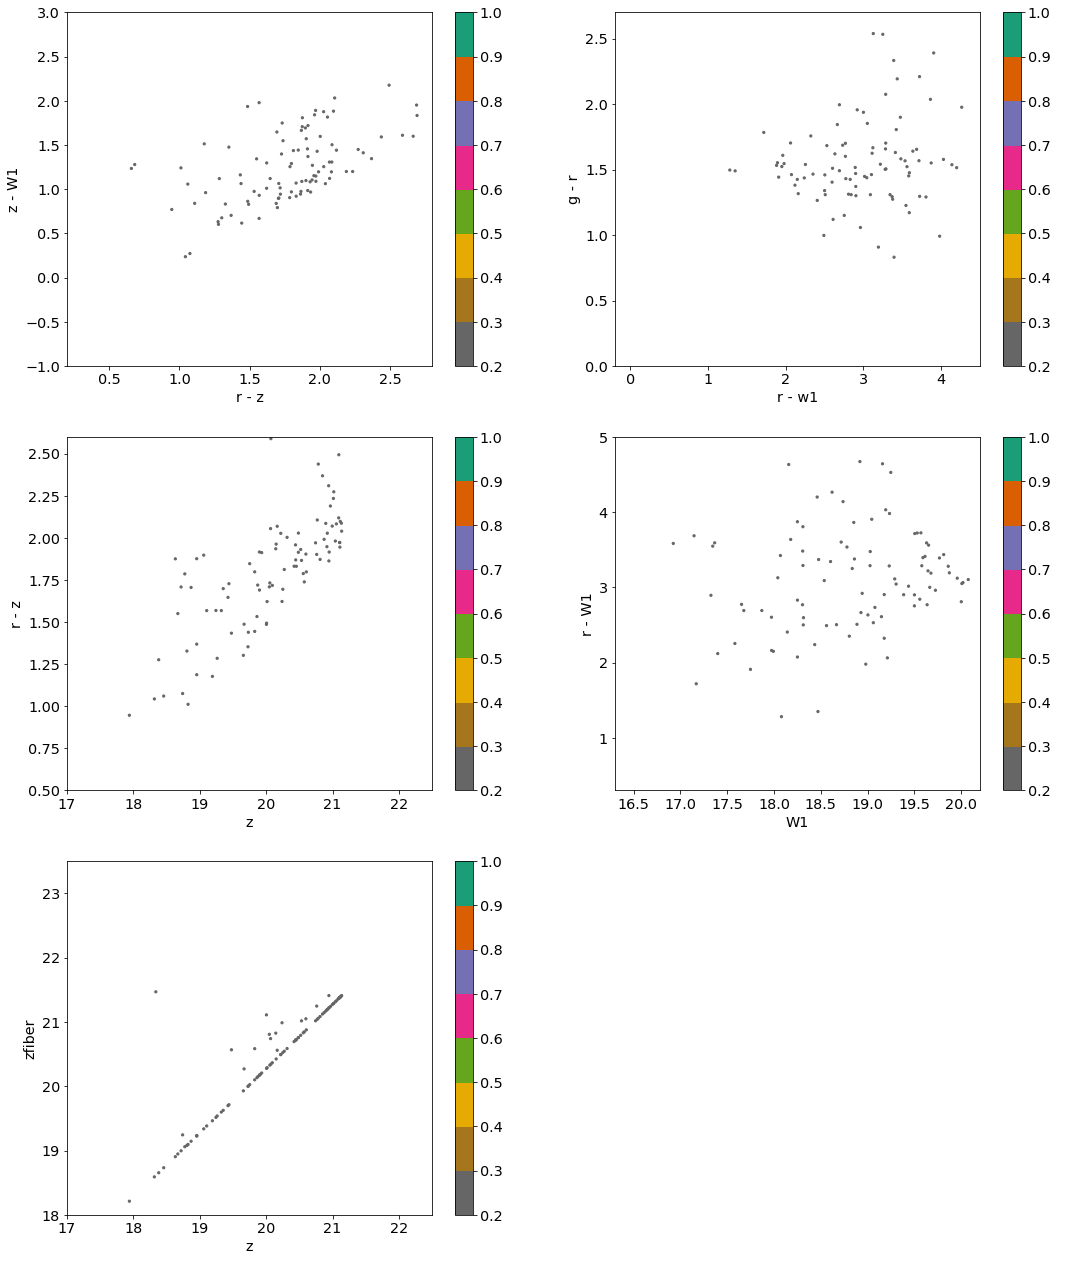

In [70]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=5)

18073


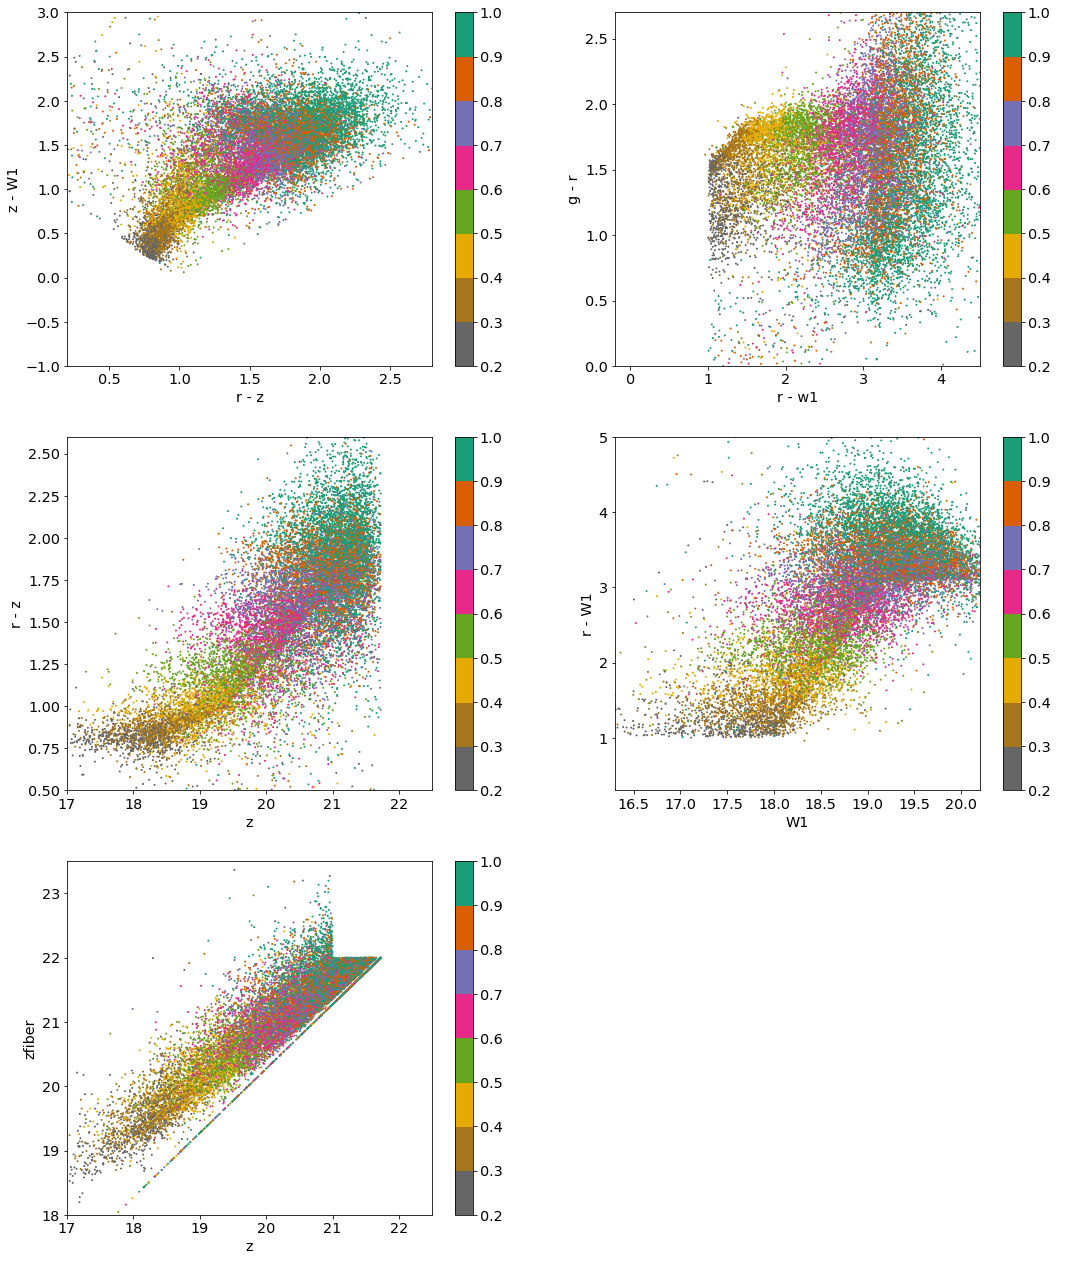

In [68]:
mask = lrg_sv & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=1)

451


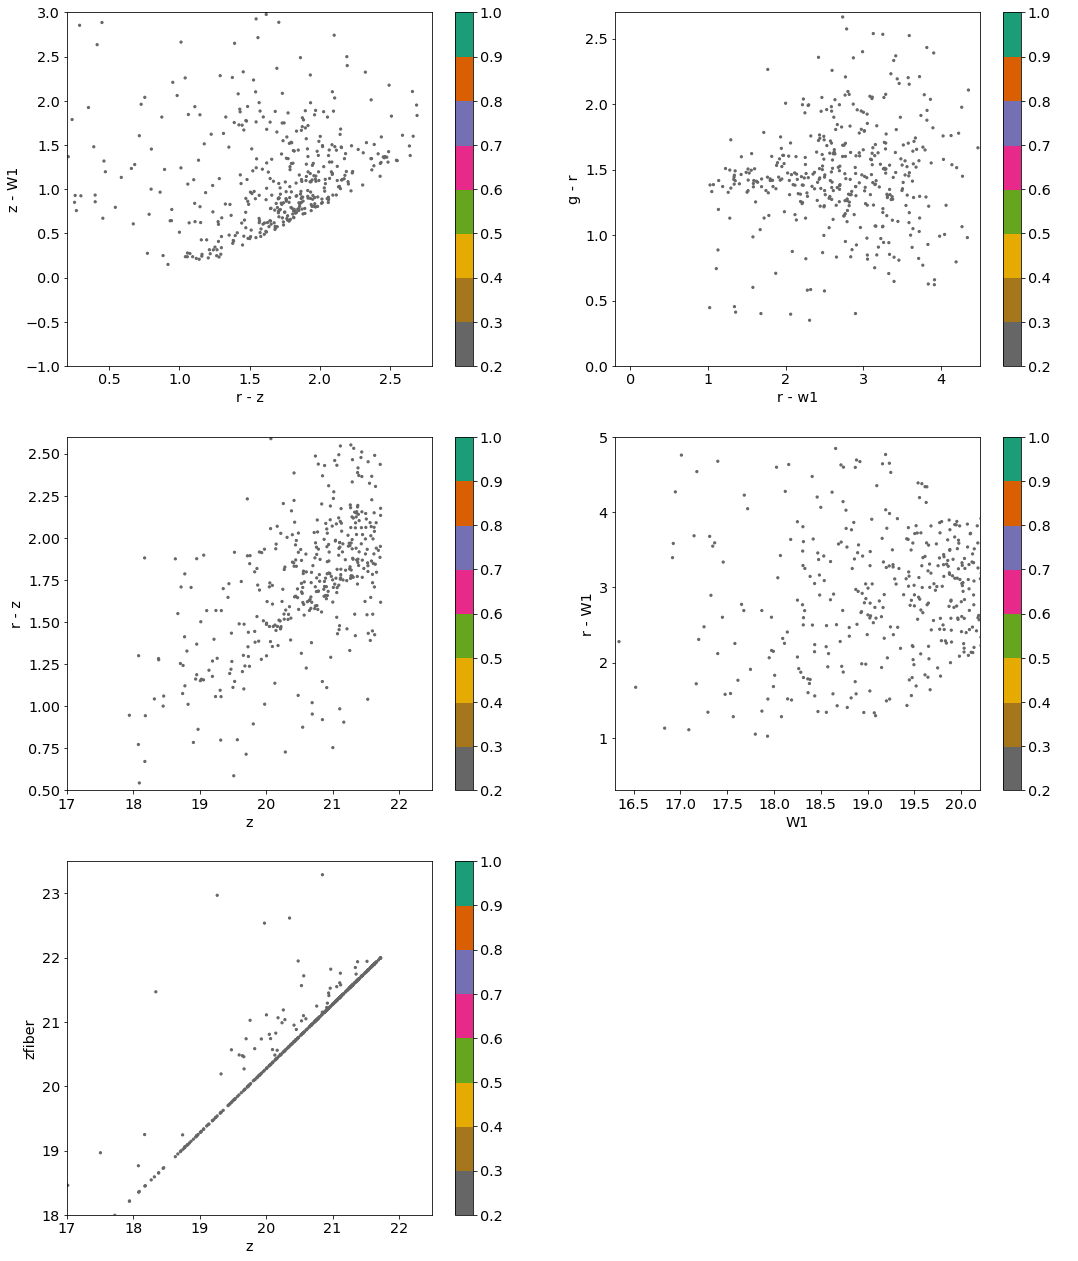

In [67]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=5)

In [35]:
mask = lrg_opt & mask_star & mask_zwarn
zbest[mask]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,NUM_TILEID,FIRST_FIBER,LAST_FIBER,NUM_FIBER,EXPS,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,subset,elgqso_weight,TARGETS,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,int16,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,float64,str7,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39628521877803343,44687.81350963001,1825.350902935285 .. 0.0,4.97729373785413e-05,1.448325414322537e-06,0,7903,STAR,K,5,55854.19072539921,0,1,9,63,9063,4699,0,155.57000866252025,31.899813898592566,0.0,0.0,2020.9651,5400.0,1297036692808663165,1,TGT,-118.265236,-103.82372,16959,3400,0.763435023282448,5,PSF,1.0696349,6.8484125,20.612947,640.93097,96.68544,1.2550247,0,,0.0,0.0,0.0,0.0,0.020030547,84.6366,72.66847,0.8324229,5.329646,16.041634,5.610833,19.142714,48.659805,128,0.0,0.0,0.0,0.0,S,1297036692808663165,1048592,0,3400,1,9010,506118,1554p320,4431,1e+20,1e+20,1e+20,1e+20,0,0,0,999999,2,-118.253,-103.8,0.0015000000000000002,0.00033333333333333365,155.5700015079964,31.899815257673268,20201219,68858,59203.43642803,80622,6,0.005369667897862337,0.005066228051190221,20201219,20201221,2,68858,69269,6,80622,80622,1,4699,4699,1,"68858,68859,68879,69267,69268,69269",6307.9998779296875,5790.699890136719,6188.199951171875,5514.6220703125,5283.7022705078125,5882.4495849609375,5380.721243321896,81833.24011230469,457.54018557071686,727.068065404892,deep,1.0,QSO+LRG,22.42691,20.411026,19.21465,17.681105,17.846634,0.036928255,0.014850106,0.043304574,20.683254,19.486877,4.97729373785413e-05
39633314159526917,20785.53205641708,-89.83330773561546 .. 0.0,-3.7063443286889076e-05,1.233717291711885e-05,0,7929,STAR,M,5,1179.6059589872639,0,1,0,449,449,451,0,106.81349266557604,54.61804018709363,0.0,0.0,2020.9487,5400.0,3407977,1,TGT,-9.329903,-373.5488,0,3200,0.7780769510031845,1,PSF,0.1154483,0.54892427,3.5854523,718.0813,268.2835,105.74376,0,,0.0,0.0,0.0,0.0,0.059458654,14.150066,1.5690776,0.08992072,0.42754775,2.7926478,0.090254046,0.4285814,2.794724,256,0.0,0.0,0.0,0.0,N,3407977,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,-9.367,-373.508,0.0008571428571428572,-0.0002142857142857143,106

In [36]:
mask = lrg_opt & mask_zwarn
mask &= zbest['MASKBITS'] & 2**8>0
print(np.sum(mask))
zbest[mask]

30


TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_NIGHT,LAST_NIGHT,NUM_NIGHT,FIRST_EXPID,LAST_EXPID,NUM_EXPID,FIRST_TILEID,LAST_TILEID,NUM_TILEID,FIRST_FIBER,LAST_FIBER,NUM_FIBER,EXPS,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,subset,elgqso_weight,TARGETS,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,int16,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,str167,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str8,float64,str7,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
39627847635046841,21411.44572287053,64.4712095182542 .. -5.149580734684673,0.765341413003753,0.00010211364911115658,0,7930,GALAXY,,10,649.2647235170007,0,1,3,37,3037,1526,0,149.7350904464339,2.411861469680825,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,93.671005,50.285503,0,3200,0.044915002087303035,1,DEV,0.968269,2.3265707,9.5674095,209.87999,99.18268,17.690256,0,,0.0,0.0,0.0,0.0,0.02094013,25.125689,22.831797,0.27969474,0.67205465,2.7636476,0.27981606,0.67231166,2.7639813,2816,4.0,1.624775,-0.13368683,-0.26354256,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,93.664,50.293,0.0028461538461538455,-0.0008461538461538464,149.73507881007697,2.411857994304201,20201214,67781,59198.43399897,80609,13,0.007671124679351381,0.009587652315508574,20201214,20201217,4,67781,68490,13,80609,80609,1,1526,1526,1,"67781,67783,68063,68064,68065,68334,68336,68337,68338,68339,68340,68489,68490",10984.599914550781,7969.700042724609,7215.700103759766,8965.964721679688,7011.713165283203,6717.894836425781,6665.289429366589,124337.3544921875,649.6725469827652,1087.929132938385,deep,1.0,QSO+LRG,22.53501,21.58321,20.048014,18.999704,19.10365,0.07128833,0.04315845,0.024850698,22.931488,21.396294,0.765341413003753
39627847668598611,17619.173988752067,132.68604522560787 .. 5.368766817477418,0.7488449584526631,9.226397735939407e-05,0,7922,GALAXY,,10,1025.3484944179654,0,1,7,494,7494,3813,0,151.5972616617636,2.460801804109923,0.0,0.0,2020.9487,5400.0,41943081,1,TGT,-372.34732,64.0592,0,3200,0.005504482318442028,1,DEV,0.42345166,1.9141861,9.119796,398.44092,189.70227,25.340734,0,,0.0,0.0,0.0,0.0,0.04254677,22.412022,4.0387583,0.13183679,0.5959597,2.839343,0.13682634,0.60204005,2.8502398,768,4.0,1.4316254,-0.14719439,-0.23938365,S,41943081,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,-372.236,63.98

----------
# Delta-chi-square

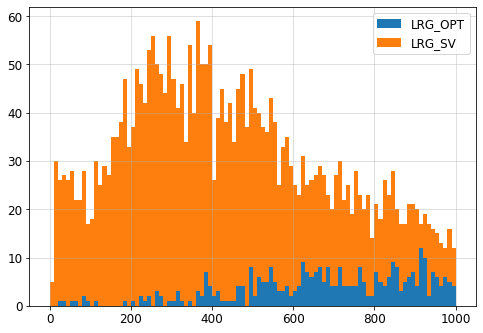

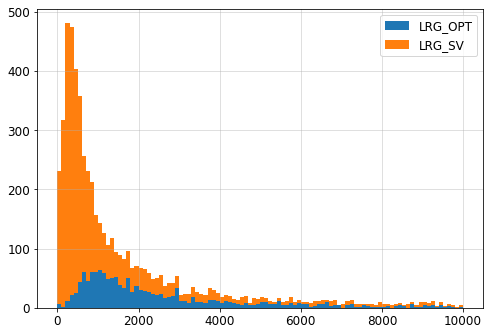

In [37]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT', zorder=2)
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 1000.), label='LRG_SV', zorder=1)
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 10000.), label='LRG_OPT', zorder=2)
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 10000.), label='LRG_SV', zorder=1)
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

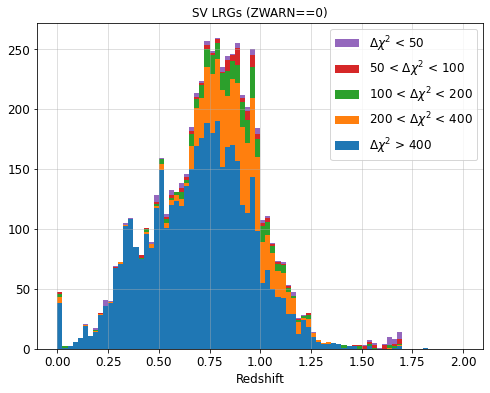

In [38]:
plt.figure(figsize=(8, 6))
mask_dchi2 = zbest['DELTACHI2']>0
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C4', range=(0, 2.0), label='$\Delta \chi^2$ < 50')
mask_dchi2 = zbest['DELTACHI2']>50
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C3', range=(0, 2.0), label='50 < $\Delta \chi^2$ < 100')
mask_dchi2 = zbest['DELTACHI2']>100
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C2', range=(0, 2.0), label='100 < $\Delta \chi^2$ < 200')
mask_dchi2 = zbest['DELTACHI2']>200
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C1', range=(0, 2.0), label='200 < $\Delta \chi^2$ < 400')
mask_dchi2 = zbest['DELTACHI2']>400
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=80, color='C0', range=(0, 2.0), label='$\Delta \chi^2$ > 400')
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.title('SV LRGs (ZWARN==0)')
# plt.ylim(0, 120)
plt.show()

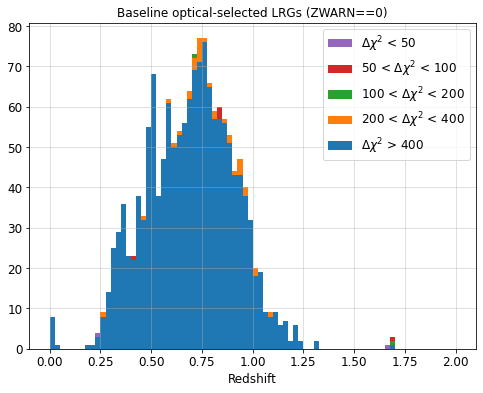

In [39]:
plt.figure(figsize=(8, 6))
mask_dchi2 = zbest['DELTACHI2']>0
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C4', range=(0, 2.0), label='$\Delta \chi^2$ < 50')
mask_dchi2 = zbest['DELTACHI2']>50
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C3', range=(0, 2.0), label='50 < $\Delta \chi^2$ < 100')
mask_dchi2 = zbest['DELTACHI2']>100
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C2', range=(0, 2.0), label='100 < $\Delta \chi^2$ < 200')
mask_dchi2 = zbest['DELTACHI2']>200
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C1', range=(0, 2.0), label='200 < $\Delta \chi^2$ < 400')
mask_dchi2 = zbest['DELTACHI2']>400
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=80, color='C0', range=(0, 2.0), label='$\Delta \chi^2$ > 400')
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.title('Baseline optical-selected LRGs (ZWARN==0)')
# plt.ylim(0, 120)
plt.show()

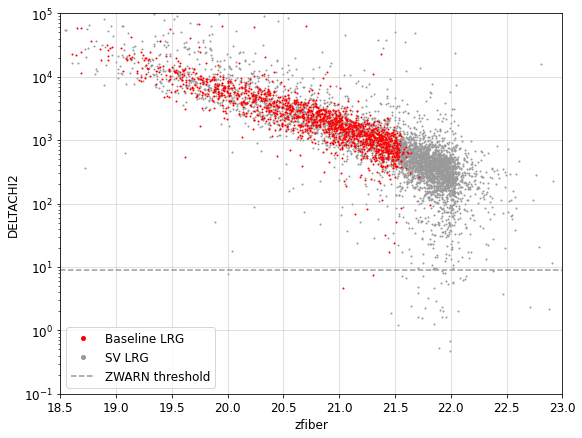

Add ZWARN cut:


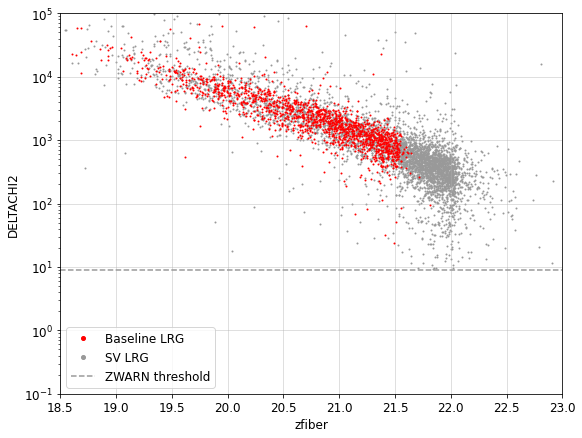

In [40]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=0)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=4)
plt.grid(alpha=0.5)
plt.show()

print('Add ZWARN cut:')
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['DELTACHI2'][lrg_opt & mask_zwarn], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv & mask_zwarn], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv & mask_zwarn], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=0)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=4)
plt.grid(alpha=0.5)
plt.show()

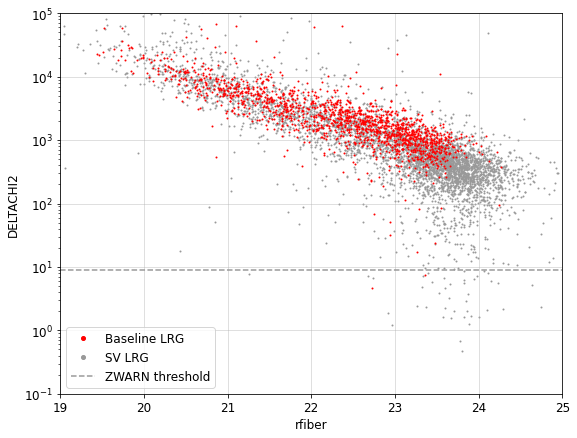

In [41]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['rfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['rfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=0)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('rfiber')
plt.ylabel('DELTACHI2')
plt.axis([19, 25, .1, 100000])
plt.legend(markerscale=4)
plt.grid(alpha=0.5)
plt.show()

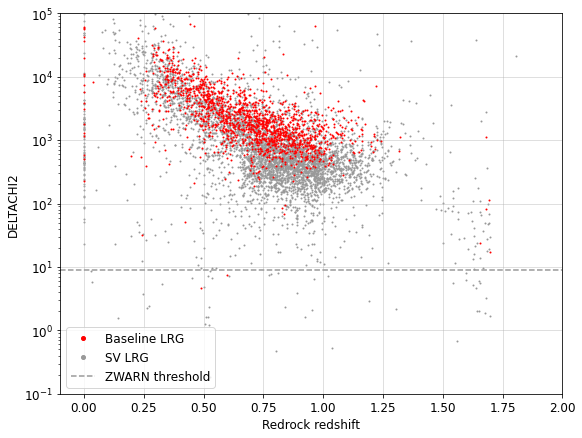

In [42]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=2, alpha=1, label='Baseline LRG', zorder=10)
plt.plot(zbest['Z'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=2, alpha=1, label='SV LRG', zorder=1)
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=4, loc='lower left')
plt.grid(alpha=0.5)
plt.show()

In [76]:
def color_plot_3x2_new(cat, selection_params=None, idx=None, title=None, vmin=0.2, vmax=1.0, cmap='Dark2_r', ms=0.3, show=True):
    '''
    Replace the g-r vs r-z panel with g-r vs r-W1
    '''
    if idx is None:
        idx = np.arange(len(cat))

    if (selection_params is not None) and ('opt_rz_slope' not in selection_params):
        selection_params['opt_rz_slope'] = 2.

    fig, axes = plt.subplots(3, 2, figsize=(18, 20))

    # non-stellar cut
    im = axes[0, 0].scatter((cat['rmag']-cat['zmag'])[idx], (cat['zmag']-cat['w1mag'])[idx], 
                c=cat['z_phot'][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 0].set_xlabel('r - z')
    axes[0, 0].set_ylabel('z - W1')
    # axes[0, 0].axis([0.2, 2.8, -1, 3])
    fig.colorbar(im, ax=axes[0, 0])
    if (selection_params is not None) and (selection_params['ns_a'] is not None) and (selection_params['ns_b'] is not None):
        x = np.linspace(0, 3)
        y = selection_params['ns_a'] * x + selection_params['ns_b']
        plt.plot(x, y, 'r--', lw=1)

    # g-r vs r-W1
    im = axes[0, 1].scatter((cat['rmag']-cat['w1mag'])[idx], (cat['gmag']-cat['rmag'])[idx], 
             c=cat['z_phot'][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 1].set_xlabel('r - w1')
    axes[0, 1].set_ylabel('g - r')
    # axes[0, 1].axis([-0.2, 4.5, 0, 2.7])
    fig.colorbar(im, ax=axes[0, 1])

    # optical sliding cut
    im = axes[1, 0].scatter((cat['zmag'])[idx], (cat['rmag']-cat['zmag'])[idx], 
             c=cat['z_phot'][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 0].set_xlabel('z')
    axes[1, 0].set_ylabel('r - z')
    # axes[1, 0].axis([17, 22.5, 0.5, 2.6])
    fig.colorbar(im, ax=axes[1, 0])
    x = np.linspace(17, 22)
    if (selection_params is not None) and (selection_params['opt_rz1'] is not None):
        y1 = (x + selection_params['opt_rz1'])/selection_params['opt_rz_slope']
        plt.plot(x, y1, 'r--', lw=1)
    if (selection_params is not None) and (selection_params['opt_rz2'] is not None):
        y2 = (x + selection_params['opt_rz2'])/selection_params['opt_rz_slope']
        plt.plot(x, y2, 'r--', lw=1)

    # IR sliding cut
    im = axes[1, 1].scatter((cat['w1mag'])[idx], (cat['rmag']-cat['w1mag'])[idx], 
             c=cat['z_phot'][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 1].set_xlabel('W1')
    axes[1, 1].set_ylabel('r - W1')
    # axes[1, 1].axis([16.3, 20.2, 0.3, 5.])
    fig.colorbar(im, ax=axes[1, 1])
    if (selection_params is not None) and (selection_params['ir_a'] is not None) and (selection_params['ir_b'] is not None):
        x = np.linspace(16, 21)
        y1 = (x + selection_params['ir_a'])/selection_params['ir_b']
        plt.plot(x, y1, 'r--', lw=1)
    
    # zfiber vs z
    im = axes[2, 0].scatter((cat['zmag'])[idx], (cat['zfibermag'])[idx], 
             c=cat['z_phot'][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2, 0].set_xlabel('z')
    axes[2, 0].set_ylabel('zfiber')
    # axes[2, 0].axis([17, 22, 18, 23])
    fig.colorbar(im, ax=axes[2, 0])

    axes[2, 1].axis('off')

    if title is not None:
        fig.suptitle(title)
    fig.subplots_adjust(top=0.96)
    
    if show:
        plt.show()
    else:
        return fig, axes
